Dataset Shape: (737453, 24)

Columns:
Index(['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='object')

Missing Values Before Cleaning:
date                            0
% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore 

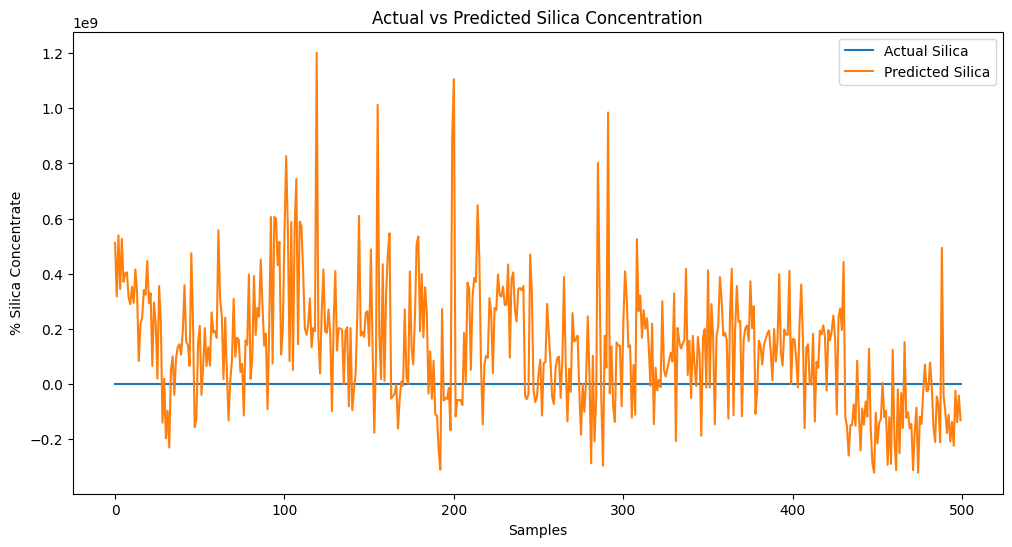

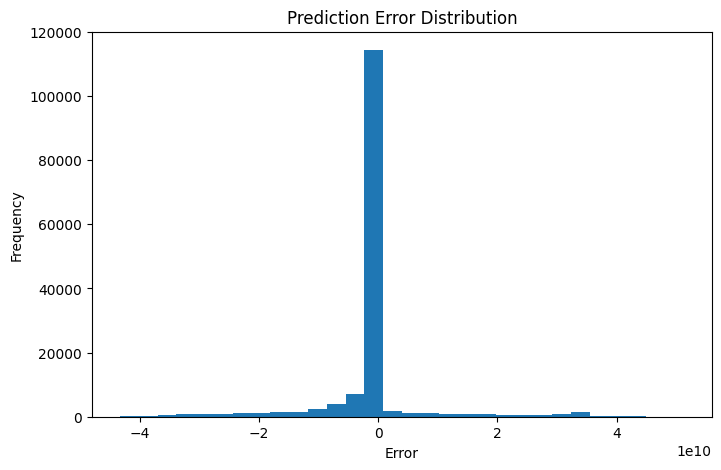

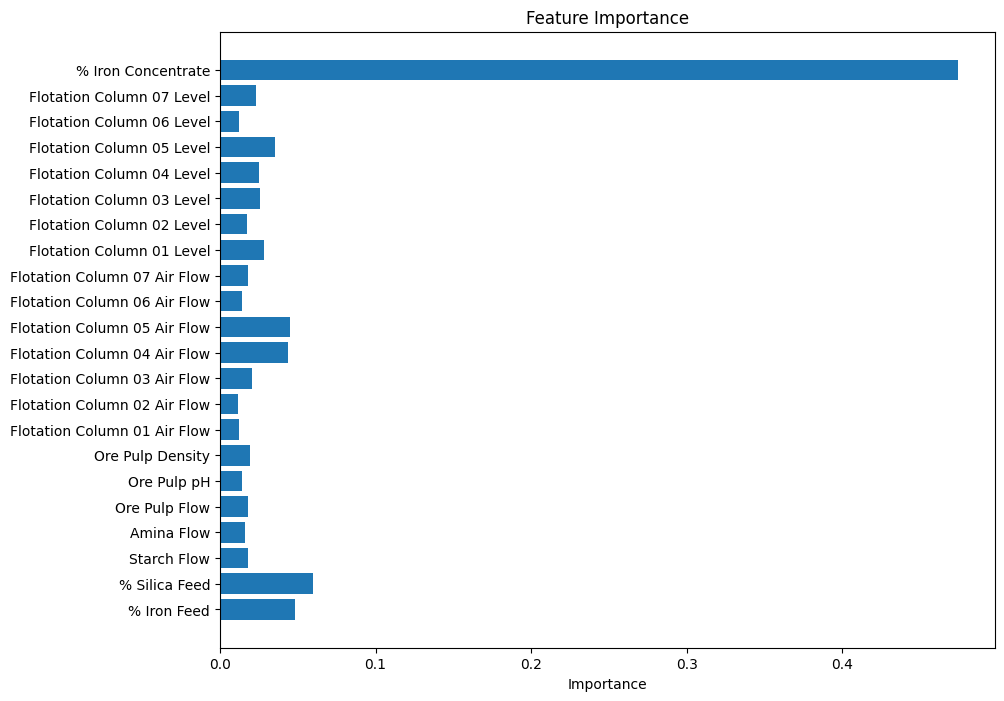


===== FUTURE PREDICTION =====
Next Predicted Silica: 725551360.0 %

===== EARLY WARNING SYSTEM =====
⚠ WARNING!
Silica concentration predicted to exceed threshold.
Recommended Action: Adjust reagent flow.

===== PROJECT OUTCOME =====
✔ Predict silica impurity in advance
✔ Help engineers reduce waste (tailings)
✔ Improve mining efficiency
✔ Improve environmental safety
✔ Enable predictive maintenance and control


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_excel("MiningProcess_Flotation_Plant_Database.csv.xlsx")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())
df.columns = df.columns.str.strip()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df = df.ffill()
print("\nMissing Values After Cleaning:")
print(df.isnull().sum().sum())
for col in df.columns:
    if col != 'date':
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',', '.'),
            errors='coerce'
        )

df = df.ffill()
target = "% Silica Concentrate"
features = [col for col in df.columns
            if col not in ['date', target]]
X = df[features]
y = df[target]
print("\nTarget Variable:", target)
print("Number of Features:", len(features))
split_index = int(len(df) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))
print("\nModel Selected: XGBoost Regressor")

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("\n===== MODEL PERFORMANCE =====")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))
results = pd.DataFrame({
    'Actual Silica': y_test.values,
    'Predicted Silica': y_pred
})
print("\nSample Predictions:")
print(results.head(10))
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:500], label="Actual Silica")
plt.plot(y_pred[:500], label="Predicted Silica")
plt.title("Actual vs Predicted Silica Concentration")
plt.xlabel("Samples")
plt.ylabel("% Silica Concentrate")
plt.legend()
plt.show()
errors = y_test - y_pred
plt.figure(figsize=(8,5))
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()
importance = model.feature_importances_
plt.figure(figsize=(10,8))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()
last_row = X.tail(1)
future_pred = model.predict(last_row)
print("\n===== FUTURE PREDICTION =====")
print("Next Predicted Silica:", round(future_pred[0], 4), "%")
threshold = 3.0
print("\n===== EARLY WARNING SYSTEM =====")
if future_pred[0] > threshold:
    print("⚠ WARNING!")
    print("Silica concentration predicted to exceed threshold.")
    print("Recommended Action: Adjust reagent flow.")
else:
    print("✅ Silica concentration within acceptable range.")
print("\n===== PROJECT OUTCOME =====")
print("✔ Predict silica impurity in advance")
print("✔ Help engineers reduce waste (tailings)")
print("✔ Improve mining efficiency")
print("✔ Improve environmental safety")
print("✔ Enable predictive maintenance and control")

